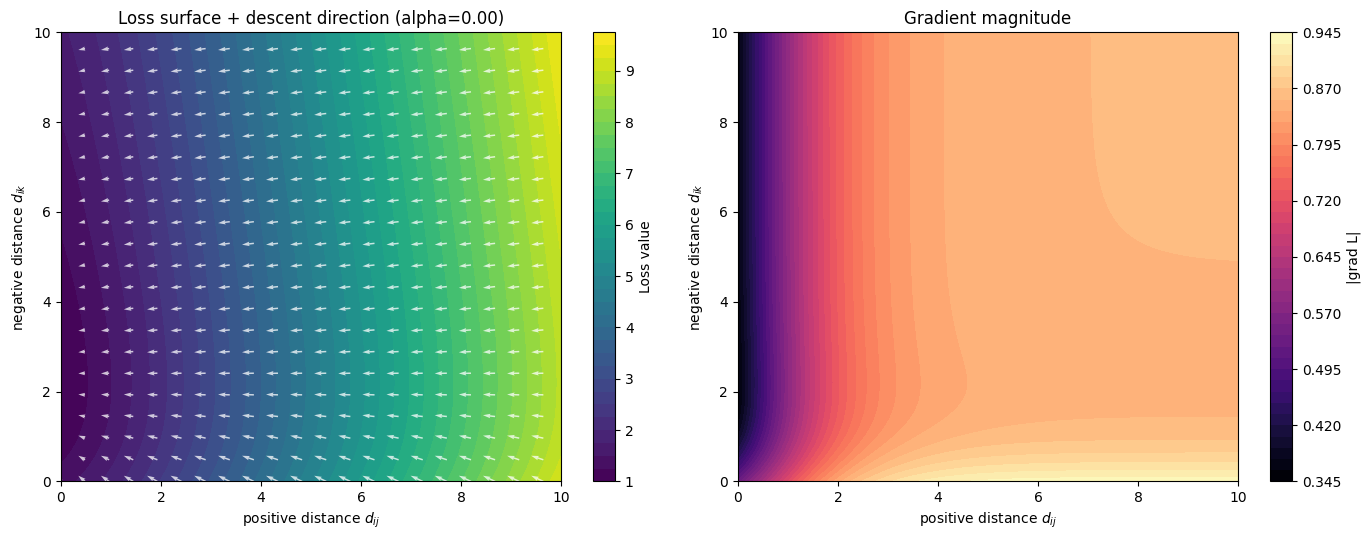

In [12]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Plot settings for the current LDM objective.
alpha = 0
positive_target = 0.85
negative_target = 0.10

x_min, x_max = 0.0, 10.0
y_min, y_max = 0.0, 10.0
num_points = 250

# Build a 2D grid of embedded distances.
x = torch.linspace(x_min, x_max, num_points)
y = torch.linspace(y_min, y_max, num_points)
D_pos, D_neg = torch.meshgrid(x, y, indexing="xy")

# Total triplet-style loss: one positive pair term + one negative pair term.
logit_pos = alpha - D_pos
logit_neg = alpha - D_neg

loss_pos = F.binary_cross_entropy_with_logits(
    logit_pos,
    torch.full_like(logit_pos, positive_target),
    reduction="none",
)
loss_neg = F.binary_cross_entropy_with_logits(
    logit_neg,
    torch.full_like(logit_neg, negative_target),
    reduction="none",
)
L = loss_pos + loss_neg

# Analytic gradients wrt distances.
sig_pos = torch.sigmoid(logit_pos)
sig_neg = torch.sigmoid(logit_neg)

dL_dd_pos = positive_target - sig_pos
dL_dd_neg = negative_target - sig_neg

grad_norm = torch.sqrt(dL_dd_pos**2 + dL_dd_neg**2)

# Gradient descent direction is the negative gradient.
stride = 12
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

contour = axes[0].contourf(D_pos.numpy(), D_neg.numpy(), L.numpy(), levels=40, cmap="viridis")
fig.colorbar(contour, ax=axes[0], label="Loss value")
axes[0].quiver(
    D_pos.numpy()[::stride, ::stride],
    D_neg.numpy()[::stride, ::stride],
    (-dL_dd_pos).numpy()[::stride, ::stride],
    (-dL_dd_neg).numpy()[::stride, ::stride],
    color="white",
    alpha=0.75,
    scale=35,
    width=0.003,
)
axes[0].set_xlabel("positive distance $d_{ij}$")
axes[0].set_ylabel("negative distance $d_{ik}$")
axes[0].set_title(f"Loss surface + descent direction (alpha={alpha:.2f})")

grad_map = axes[1].contourf(D_pos.numpy(), D_neg.numpy(), grad_norm.numpy(), levels=40, cmap="magma")
fig.colorbar(grad_map, ax=axes[1], label="|grad L|")
axes[1].set_xlabel("positive distance $d_{ij}$")
axes[1].set_ylabel("negative distance $d_{ik}$")
axes[1].set_title("Gradient magnitude")

plt.tight_layout()
plt.show()